In [1]:
from __future__ import annotations

import os
import time
from getpass import getpass
from pathlib import Path
from typing import Any

import httpx
import weaviate
import weaviate.classes as wvc

from google import genai
from google.genai import types
from IPython.display import Image, display

from weaviate.classes.init import Auth
from weaviate.classes.query import MetadataQuery

In [2]:
if "WEAVIATE_URL" not in os.environ:
    os.environ["WEAVIATE_URL"] = getpass("WEAVIATE_URL: ")

if "WEAVIATE_API_KEY" not in os.environ:
    os.environ["WEAVIATE_API_KEY"] = getpass("WEAVIATE_API_KEY: ")

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass("GOOGLE_API_KEY: ")

In [3]:
google_client = genai.Client(
    api_key=os.environ["GOOGLE_API_KEY"],
)

client = weaviate.connect_to_weaviate_cloud(
    cluster_url=os.environ["WEAVIATE_URL"],
    auth_credentials=Auth.api_key(os.environ["WEAVIATE_API_KEY"]),
    headers={
        "X-Goog-Studio-Api-Key": os.environ["GOOGLE_API_KEY"],
    },
)

print("Weaviate client ready:", client.is_ready())

Weaviate client ready: True


In [4]:
GOOGLE_EMBEDDING_MODEL = "gemini-embedding-2"
GOOGLE_GENERATIVE_MODEL = "gemini-2.5-flash"

EMBEDDING_DIMENSIONS = 768
IMAGE_WIDTH = 384
IMAGE_HEIGHT = 256
IMAGE_LIMIT = 12

IMAGE_DIR = Path("vector_db/assets/gemini_embedding_2_images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print("Image directory:", IMAGE_DIR)
print("Embedding model:", GOOGLE_EMBEDDING_MODEL)
print("Embedding dimensions:", EMBEDDING_DIMENSIONS)

Image directory: vector_db/assets/gemini_embedding_2_images
Embedding model: gemini-embedding-2
Embedding dimensions: 768


In [5]:
def get_json(
    url: str,
    *,
    params: dict[str, Any] | None = None,
) -> dict[str, Any] | list[dict[str, Any]]:
    headers = {
        "User-Agent": "PythonPracticeNotebook/1.0 educational project",
        "Accept": "application/json",
    }

    with httpx.Client(
        timeout=30.0,
        follow_redirects=True,
        headers=headers,
    ) as http_client:
        response = http_client.get(url, params=params)
        response.raise_for_status()
        return response.json()


def download_binary(
    url: str,
    output_path: Path,
) -> None:
    headers = {
        "User-Agent": "PythonPracticeNotebook/1.0 educational project",
        "Accept": "image/jpeg,image/png,*/*",
    }

    with httpx.Client(
        timeout=30.0,
        follow_redirects=True,
        headers=headers,
    ) as http_client:
        response = http_client.get(url)
        response.raise_for_status()
        output_path.write_bytes(response.content)

In [7]:
def fetch_picsum_image_list(
    *,
    page: int = 1,
    limit: int = IMAGE_LIMIT,
) -> list[dict[str, Any]]:
    url = "https://picsum.photos/v2/list"

    data = get_json(
        url,
        params={
            "page": page,
            "limit": limit,
        },
    )

    if not isinstance(data, list):
        raise RuntimeError("Unexpected Picsum response format.")

    return data


image_items = fetch_picsum_image_list(
    page=1,
    limit=IMAGE_LIMIT,
)

print("Images from API:", len(image_items))

for item in image_items[:5]:
    print(item)

Images from API: 12
{'id': '0', 'author': 'Alejandro Escamilla', 'width': 5000, 'height': 3333, 'url': 'https://unsplash.com/photos/yC-Yzbqy7PY', 'download_url': 'https://picsum.photos/id/0/5000/3333'}
{'id': '1', 'author': 'Alejandro Escamilla', 'width': 5000, 'height': 3333, 'url': 'https://unsplash.com/photos/LNRyGwIJr5c', 'download_url': 'https://picsum.photos/id/1/5000/3333'}
{'id': '2', 'author': 'Alejandro Escamilla', 'width': 5000, 'height': 3333, 'url': 'https://unsplash.com/photos/N7XodRrbzS0', 'download_url': 'https://picsum.photos/id/2/5000/3333'}
{'id': '3', 'author': 'Alejandro Escamilla', 'width': 5000, 'height': 3333, 'url': 'https://unsplash.com/photos/Dl6jeyfihLk', 'download_url': 'https://picsum.photos/id/3/5000/3333'}
{'id': '4', 'author': 'Alejandro Escamilla', 'width': 5000, 'height': 3333, 'url': 'https://unsplash.com/photos/y83Je1OC6Wc', 'download_url': 'https://picsum.photos/id/4/5000/3333'}


In [8]:
def build_resized_picsum_url(
    image_id: str,
    *,
    width: int = IMAGE_WIDTH,
    height: int = IMAGE_HEIGHT,
) -> str:
    return f"https://picsum.photos/id/{image_id}/{width}/{height}.jpg"


downloaded_images = []

for item in image_items:
    image_id = str(item["id"])
    author = item.get("author", "unknown")
    original_url = item.get("url", "")
    resized_url = build_resized_picsum_url(image_id)

    filename = f"picsum_{image_id}_{IMAGE_WIDTH}x{IMAGE_HEIGHT}.jpg"
    image_path = IMAGE_DIR / filename

    if not image_path.exists():
        print("Downloading:", resized_url)
        download_binary(resized_url, image_path)
        time.sleep(0.2)
    else:
        print("Already exists:", image_path)

    downloaded_images.append(
        {
            "image_id": image_id,
            "author": author,
            "original_url": original_url,
            "image_url": resized_url,
            "filename": filename,
            "local_path": str(image_path),
        }
    )

print("Downloaded images:", len(downloaded_images))

Downloading: https://picsum.photos/id/0/384/256.jpg
Downloading: https://picsum.photos/id/1/384/256.jpg
Downloading: https://picsum.photos/id/2/384/256.jpg
Downloading: https://picsum.photos/id/3/384/256.jpg
Downloading: https://picsum.photos/id/4/384/256.jpg
Downloading: https://picsum.photos/id/5/384/256.jpg
Downloading: https://picsum.photos/id/6/384/256.jpg
Downloading: https://picsum.photos/id/7/384/256.jpg
Downloading: https://picsum.photos/id/8/384/256.jpg
Downloading: https://picsum.photos/id/9/384/256.jpg
Downloading: https://picsum.photos/id/10/384/256.jpg
Downloading: https://picsum.photos/id/11/384/256.jpg
Downloaded images: 12


ID: 0
Author: Alejandro Escamilla
Path: vector_db/assets/gemini_embedding_2_images/picsum_0_384x256.jpg


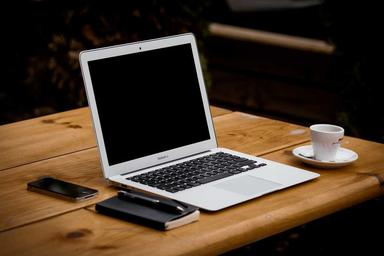

----------------------------------------------------------------------------------------------------
ID: 1
Author: Alejandro Escamilla
Path: vector_db/assets/gemini_embedding_2_images/picsum_1_384x256.jpg


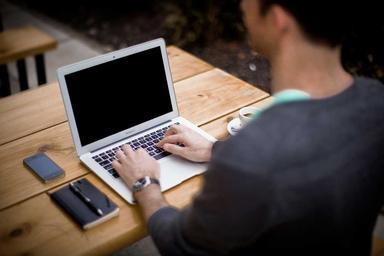

----------------------------------------------------------------------------------------------------
ID: 2
Author: Alejandro Escamilla
Path: vector_db/assets/gemini_embedding_2_images/picsum_2_384x256.jpg


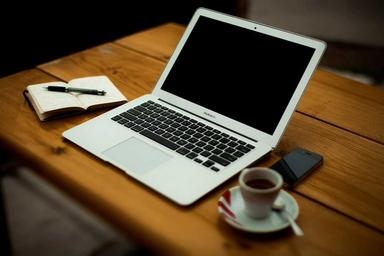

----------------------------------------------------------------------------------------------------
ID: 3
Author: Alejandro Escamilla
Path: vector_db/assets/gemini_embedding_2_images/picsum_3_384x256.jpg


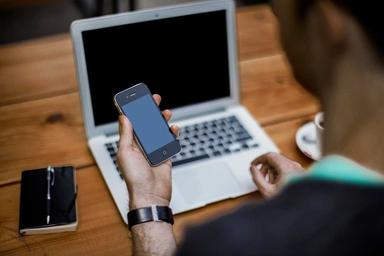

----------------------------------------------------------------------------------------------------
ID: 4
Author: Alejandro Escamilla
Path: vector_db/assets/gemini_embedding_2_images/picsum_4_384x256.jpg


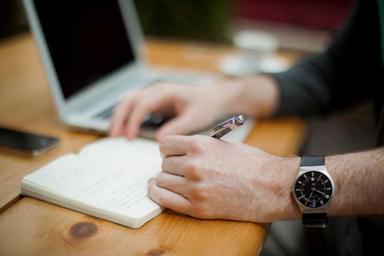

----------------------------------------------------------------------------------------------------


In [9]:
for image_record in downloaded_images[:5]:
    print("ID:", image_record["image_id"])
    print("Author:", image_record["author"])
    print("Path:", image_record["local_path"])
    display(Image(filename=image_record["local_path"], width=260))
    print("-" * 100)

In [10]:
def embed_image_with_gemini(
    image_path: str | Path,
    *,
    output_dimensionality: int = EMBEDDING_DIMENSIONS,
) -> list[float]:
    image_path = Path(image_path)
    image_bytes = image_path.read_bytes()

    result = google_client.models.embed_content(
        model=GOOGLE_EMBEDDING_MODEL,
        contents=[
            types.Part.from_bytes(
                data=image_bytes,
                mime_type="image/jpeg",
            ),
        ],
        config={
            "output_dimensionality": output_dimensionality,
        },
    )

    return list(result.embeddings[0].values)

In [11]:
def embed_text_query_with_gemini(
    query: str,
    *,
    output_dimensionality: int = EMBEDDING_DIMENSIONS,
) -> list[float]:
    prepared_query = f"task: search result | query: {query}"

    result = google_client.models.embed_content(
        model=GOOGLE_EMBEDDING_MODEL,
        contents=prepared_query,
        config={
            "output_dimensionality": output_dimensionality,
        },
    )

    return list(result.embeddings[0].values)

In [12]:
test_embedding = embed_image_with_gemini(downloaded_images[0]["local_path"])

print("Embedding type:", type(test_embedding))
print("Embedding length:", len(test_embedding))
print("First 10 values:", test_embedding[:10])

Embedding type: <class 'list'>
Embedding length: 768
First 10 values: [-0.016522616, -0.06664557, 0.013257107, 0.0009918185, -0.006479253, 0.0043104845, -0.010580085, 0.019281145, -0.017246574, -0.026389373]


In [13]:
image_records = []

for image_record in downloaded_images:
    print("Embedding image:", image_record["filename"])

    try:
        embedding = embed_image_with_gemini(image_record["local_path"])

        description = (
            f"Image from Lorem Picsum. "
            f"Image id: {image_record['image_id']}. "
            f"Author: {image_record['author']}. "
            f"Local file: {image_record['filename']}."
        )

        image_records.append(
            {
                **image_record,
                "description": description,
                "embedding": embedding,
            }
        )

        time.sleep(0.5)

    except Exception as error:
        print("Failed:", image_record["filename"])
        print(repr(error))

print("Image records with embeddings:", len(image_records))

Embedding image: picsum_0_384x256.jpg
Embedding image: picsum_1_384x256.jpg
Embedding image: picsum_2_384x256.jpg
Embedding image: picsum_3_384x256.jpg
Embedding image: picsum_4_384x256.jpg
Embedding image: picsum_5_384x256.jpg
Embedding image: picsum_6_384x256.jpg
Embedding image: picsum_7_384x256.jpg
Embedding image: picsum_8_384x256.jpg
Embedding image: picsum_9_384x256.jpg
Embedding image: picsum_10_384x256.jpg
Embedding image: picsum_11_384x256.jpg
Image records with embeddings: 12


In [14]:
COLLECTION_NAME = "GeminiEmbedding2ImageSearch"

if client.collections.exists(COLLECTION_NAME):
    client.collections.delete(COLLECTION_NAME)

image_collection = client.collections.create(
    name=COLLECTION_NAME,
    vector_config=wvc.config.Configure.Vectors.self_provided(
        name="image_vector",
    ),
    generative_config=wvc.config.Configure.Generative.google_gemini(
        model=GOOGLE_GENERATIVE_MODEL,
        temperature=0.2,
        max_output_tokens=700,
    ),
    properties=[
        wvc.config.Property(name="image_id", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="author", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="original_url", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="image_url", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="filename", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="local_path", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="description", data_type=wvc.config.DataType.TEXT),
    ],
)

print("Created collection:", COLLECTION_NAME)

Created collection: GeminiEmbedding2ImageSearch


In [15]:
if not image_records:
    raise RuntimeError("No image records to import.")

for record in image_records:
    embedding = record["embedding"]

    properties = {
        key: value
        for key, value in record.items()
        if key != "embedding"
    }

    image_collection.data.insert(
        properties=properties,
        vector={
            "image_vector": embedding,
        },
    )

print("Imported image records:", len(image_records))

Imported image records: 12


In [16]:
response = image_collection.aggregate.over_all(total_count=True)

print("Total objects:", response.total_count)

Total objects: 12


UUID: 031d48ec-bb45-437d-9b9d-50a744a6a10b
Image ID: 6
Author: Alejandro Escamilla
Filename: picsum_6_384x256.jpg
URL: https://picsum.photos/id/6/384/256.jpg


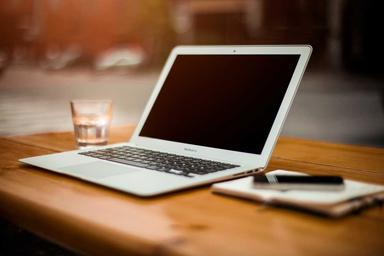

----------------------------------------------------------------------------------------------------
UUID: 1ae89e3b-696d-4dcc-980a-ad067e2eeb9d
Image ID: 11
Author: Paul Jarvis
Filename: picsum_11_384x256.jpg
URL: https://picsum.photos/id/11/384/256.jpg


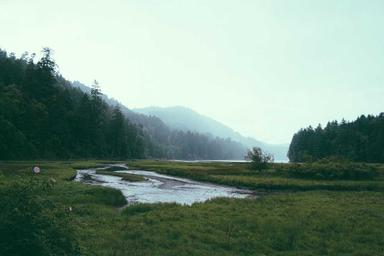

----------------------------------------------------------------------------------------------------
UUID: 23970f38-f08c-41aa-84dd-3eb3f6de7d47
Image ID: 7
Author: Alejandro Escamilla
Filename: picsum_7_384x256.jpg
URL: https://picsum.photos/id/7/384/256.jpg


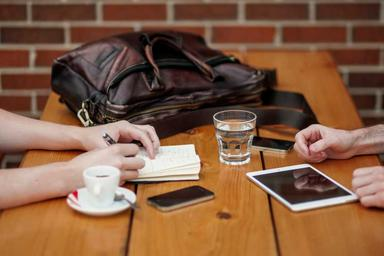

----------------------------------------------------------------------------------------------------
UUID: 33335ef3-e774-40f3-81f0-f91bc078063c
Image ID: 4
Author: Alejandro Escamilla
Filename: picsum_4_384x256.jpg
URL: https://picsum.photos/id/4/384/256.jpg


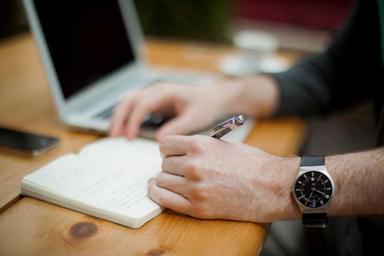

----------------------------------------------------------------------------------------------------
UUID: 3ea9b120-9f79-4cf6-a766-bffd472035f4
Image ID: 0
Author: Alejandro Escamilla
Filename: picsum_0_384x256.jpg
URL: https://picsum.photos/id/0/384/256.jpg


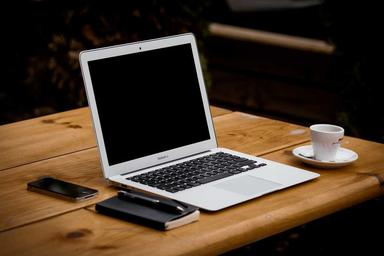

----------------------------------------------------------------------------------------------------


In [17]:
response = image_collection.query.fetch_objects(
    limit=5,
    return_properties=[
        "image_id",
        "author",
        "filename",
        "local_path",
        "image_url",
        "description",
    ],
)

for obj in response.objects:
    print("UUID:", obj.uuid)
    print("Image ID:", obj.properties["image_id"])
    print("Author:", obj.properties["author"])
    print("Filename:", obj.properties["filename"])
    print("URL:", obj.properties["image_url"])
    display(Image(filename=obj.properties["local_path"], width=260))
    print("-" * 100)

In [18]:
def search_images_by_text(
    query: str,
    *,
    limit: int = 5,
) -> None:
    query_embedding = embed_text_query_with_gemini(query)

    response = image_collection.query.near_vector(
        near_vector=query_embedding,
        target_vector="image_vector",
        limit=limit,
        return_properties=[
            "image_id",
            "author",
            "filename",
            "local_path",
            "image_url",
            "description",
        ],
        return_metadata=MetadataQuery(distance=True),
    )

    print("QUERY:", query)
    print("-" * 100)

    for obj in response.objects:
        print("Distance:", obj.metadata.distance)
        print("Image ID:", obj.properties["image_id"])
        print("Author:", obj.properties["author"])
        print("Filename:", obj.properties["filename"])
        print("URL:", obj.properties["image_url"])
        display(Image(filename=obj.properties["local_path"], width=300))
        print("-" * 100)

QUERY: a landscape photo with mountains, forest or nature
----------------------------------------------------------------------------------------------------
Distance: 0.34430307149887085
Image ID: 11
Author: Paul Jarvis
Filename: picsum_11_384x256.jpg
URL: https://picsum.photos/id/11/384/256.jpg


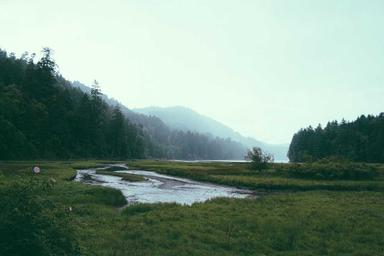

----------------------------------------------------------------------------------------------------
Distance: 0.36055243015289307
Image ID: 10
Author: Paul Jarvis
Filename: picsum_10_384x256.jpg
URL: https://picsum.photos/id/10/384/256.jpg


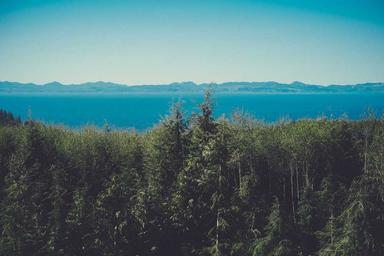

----------------------------------------------------------------------------------------------------
Distance: 0.4652247428894043
Image ID: 6
Author: Alejandro Escamilla
Filename: picsum_6_384x256.jpg
URL: https://picsum.photos/id/6/384/256.jpg


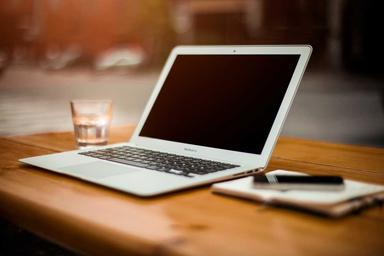

----------------------------------------------------------------------------------------------------
Distance: 0.4717831611633301
Image ID: 0
Author: Alejandro Escamilla
Filename: picsum_0_384x256.jpg
URL: https://picsum.photos/id/0/384/256.jpg


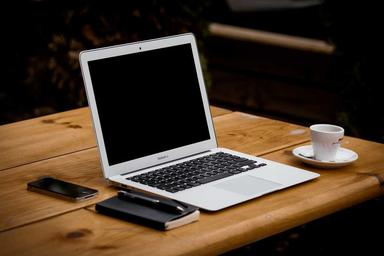

----------------------------------------------------------------------------------------------------
Distance: 0.4763675928115845
Image ID: 9
Author: Alejandro Escamilla
Filename: picsum_9_384x256.jpg
URL: https://picsum.photos/id/9/384/256.jpg


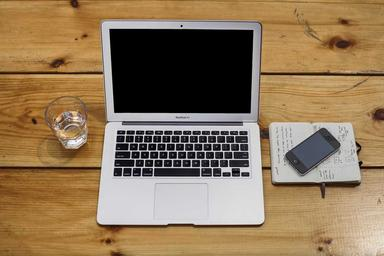

----------------------------------------------------------------------------------------------------


In [19]:
search_images_by_text(
    "a landscape photo with mountains, forest or nature",
    limit=5,
)

QUERY: a laptop
----------------------------------------------------------------------------------------------------
Distance: 0.3390986919403076
Image ID: 6
Author: Alejandro Escamilla
Filename: picsum_6_384x256.jpg
URL: https://picsum.photos/id/6/384/256.jpg


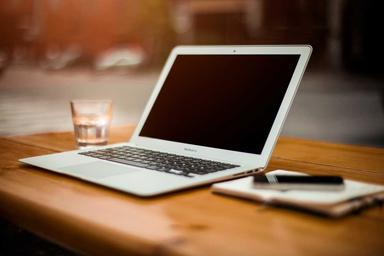

----------------------------------------------------------------------------------------------------
Distance: 0.3425334692001343
Image ID: 0
Author: Alejandro Escamilla
Filename: picsum_0_384x256.jpg
URL: https://picsum.photos/id/0/384/256.jpg


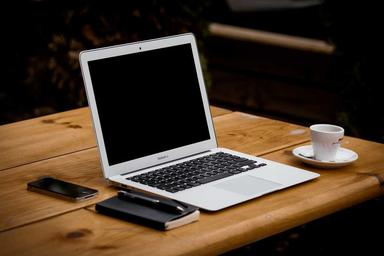

----------------------------------------------------------------------------------------------------
Distance: 0.3439742922782898
Image ID: 9
Author: Alejandro Escamilla
Filename: picsum_9_384x256.jpg
URL: https://picsum.photos/id/9/384/256.jpg


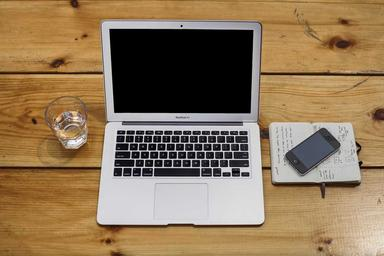

----------------------------------------------------------------------------------------------------
Distance: 0.3503892421722412
Image ID: 2
Author: Alejandro Escamilla
Filename: picsum_2_384x256.jpg
URL: https://picsum.photos/id/2/384/256.jpg


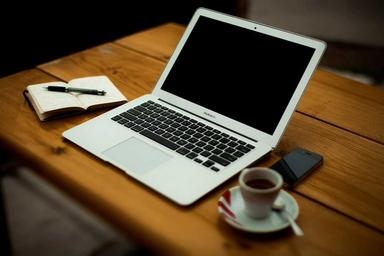

----------------------------------------------------------------------------------------------------
Distance: 0.35568928718566895
Image ID: 8
Author: Alejandro Escamilla
Filename: picsum_8_384x256.jpg
URL: https://picsum.photos/id/8/384/256.jpg


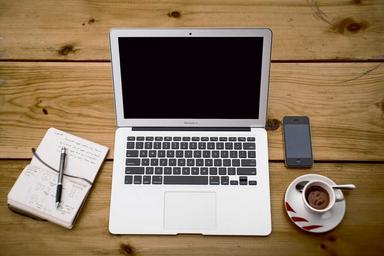

----------------------------------------------------------------------------------------------------


In [21]:
search_images_by_text(
    "a laptop",
    limit=5,
)

QUERY: a photo with water, lake, river, sea or beach
----------------------------------------------------------------------------------------------------
Distance: 0.378040075302124
Image ID: 11
Author: Paul Jarvis
Filename: picsum_11_384x256.jpg
URL: https://picsum.photos/id/11/384/256.jpg


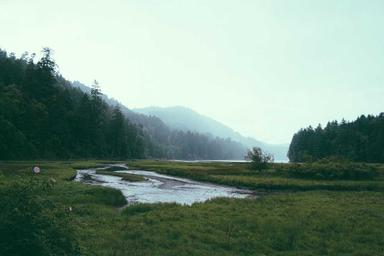

----------------------------------------------------------------------------------------------------
Distance: 0.39277660846710205
Image ID: 10
Author: Paul Jarvis
Filename: picsum_10_384x256.jpg
URL: https://picsum.photos/id/10/384/256.jpg


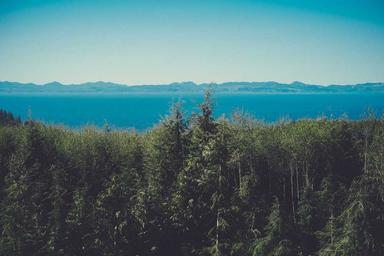

----------------------------------------------------------------------------------------------------
Distance: 0.42945194244384766
Image ID: 9
Author: Alejandro Escamilla
Filename: picsum_9_384x256.jpg
URL: https://picsum.photos/id/9/384/256.jpg


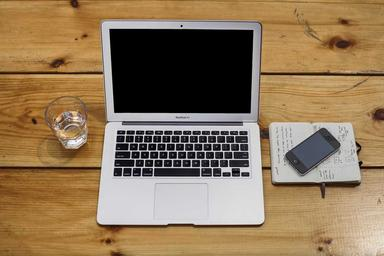

----------------------------------------------------------------------------------------------------
Distance: 0.43091994524002075
Image ID: 6
Author: Alejandro Escamilla
Filename: picsum_6_384x256.jpg
URL: https://picsum.photos/id/6/384/256.jpg


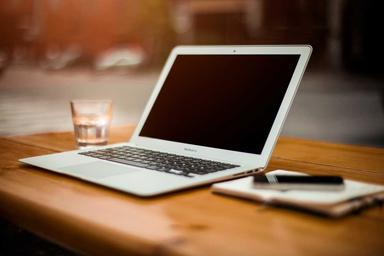

----------------------------------------------------------------------------------------------------
Distance: 0.4527987241744995
Image ID: 2
Author: Alejandro Escamilla
Filename: picsum_2_384x256.jpg
URL: https://picsum.photos/id/2/384/256.jpg


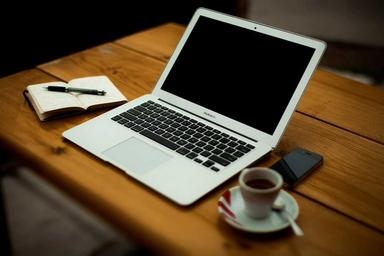

----------------------------------------------------------------------------------------------------


In [22]:
search_images_by_text(
    "a photo with water, lake, river, sea or beach",
    limit=5,
)

QUERY: a close up photo of an animal or person
----------------------------------------------------------------------------------------------------
Distance: 0.45293599367141724
Image ID: 5
Author: Alejandro Escamilla
Filename: picsum_5_384x256.jpg
URL: https://picsum.photos/id/5/384/256.jpg


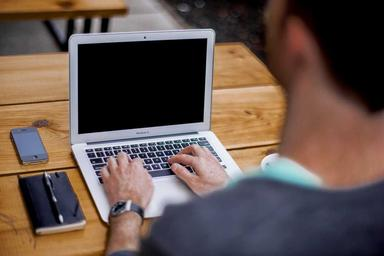

----------------------------------------------------------------------------------------------------
Distance: 0.45672959089279175
Image ID: 9
Author: Alejandro Escamilla
Filename: picsum_9_384x256.jpg
URL: https://picsum.photos/id/9/384/256.jpg


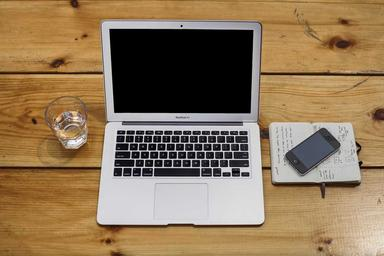

----------------------------------------------------------------------------------------------------
Distance: 0.45876652002334595
Image ID: 6
Author: Alejandro Escamilla
Filename: picsum_6_384x256.jpg
URL: https://picsum.photos/id/6/384/256.jpg


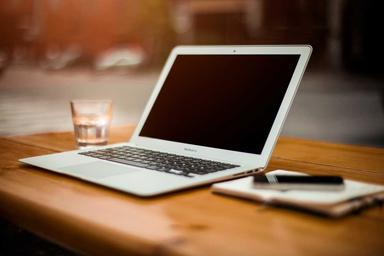

----------------------------------------------------------------------------------------------------
Distance: 0.4597066044807434
Image ID: 11
Author: Paul Jarvis
Filename: picsum_11_384x256.jpg
URL: https://picsum.photos/id/11/384/256.jpg


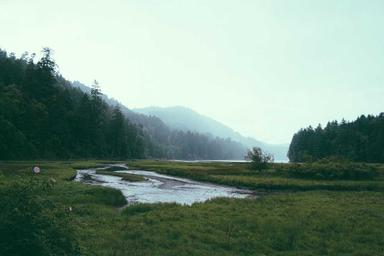

----------------------------------------------------------------------------------------------------
Distance: 0.46285372972488403
Image ID: 0
Author: Alejandro Escamilla
Filename: picsum_0_384x256.jpg
URL: https://picsum.photos/id/0/384/256.jpg


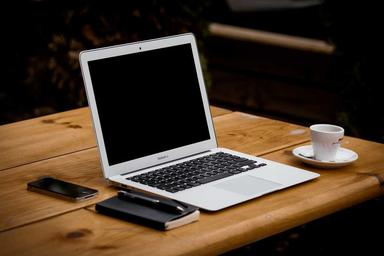

----------------------------------------------------------------------------------------------------


In [23]:
search_images_by_text(
    "a close up photo of an animal or person",
    limit=5,
)

In [24]:
def search_images_by_image(
    image_path: str | Path,
    *,
    limit: int = 5,
) -> None:
    query_embedding = embed_image_with_gemini(image_path)

    response = image_collection.query.near_vector(
        near_vector=query_embedding,
        target_vector="image_vector",
        limit=limit,
        return_properties=[
            "image_id",
            "author",
            "filename",
            "local_path",
            "image_url",
            "description",
        ],
        return_metadata=MetadataQuery(distance=True),
    )

    print("QUERY IMAGE:")
    display(Image(filename=str(image_path), width=320))
    print("-" * 100)

    for obj in response.objects:
        print("Distance:", obj.metadata.distance)
        print("Image ID:", obj.properties["image_id"])
        print("Author:", obj.properties["author"])
        print("Filename:", obj.properties["filename"])
        display(Image(filename=obj.properties["local_path"], width=300))
        print("-" * 100)

QUERY IMAGE:


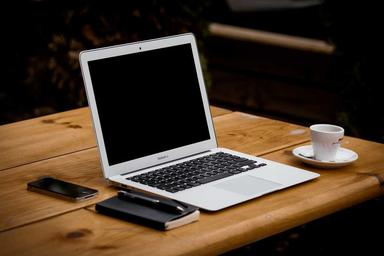

----------------------------------------------------------------------------------------------------
Distance: 4.172325134277344e-07
Image ID: 0
Author: Alejandro Escamilla
Filename: picsum_0_384x256.jpg


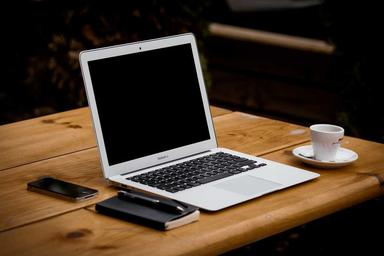

----------------------------------------------------------------------------------------------------
Distance: 0.021997809410095215
Image ID: 2
Author: Alejandro Escamilla
Filename: picsum_2_384x256.jpg


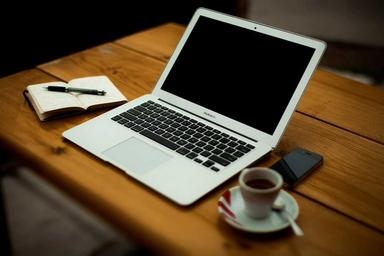

----------------------------------------------------------------------------------------------------
Distance: 0.03742992877960205
Image ID: 8
Author: Alejandro Escamilla
Filename: picsum_8_384x256.jpg


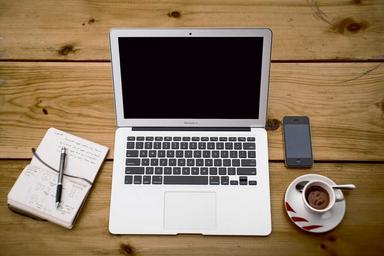

----------------------------------------------------------------------------------------------------
Distance: 0.04814040660858154
Image ID: 6
Author: Alejandro Escamilla
Filename: picsum_6_384x256.jpg


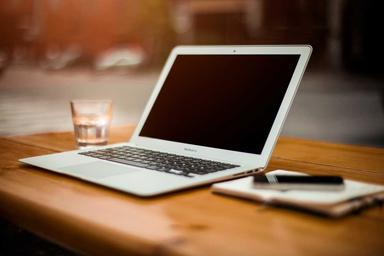

----------------------------------------------------------------------------------------------------
Distance: 0.060443997383117676
Image ID: 9
Author: Alejandro Escamilla
Filename: picsum_9_384x256.jpg


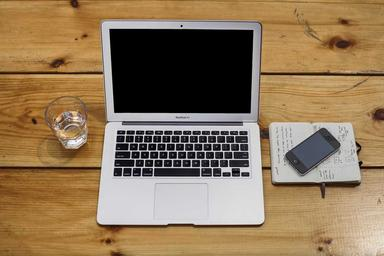

----------------------------------------------------------------------------------------------------


In [25]:
search_images_by_image(
    downloaded_images[0]["local_path"],
    limit=5,
)

QUERY IMAGE:


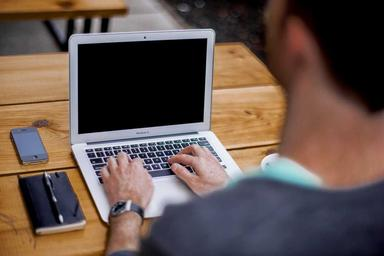

----------------------------------------------------------------------------------------------------
Distance: 5.960464477539063e-08
Image ID: 5
Author: Alejandro Escamilla
Filename: picsum_5_384x256.jpg


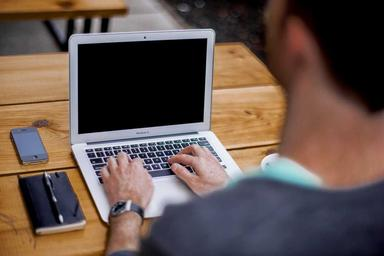

----------------------------------------------------------------------------------------------------
Distance: 0.0234982967376709
Image ID: 1
Author: Alejandro Escamilla
Filename: picsum_1_384x256.jpg


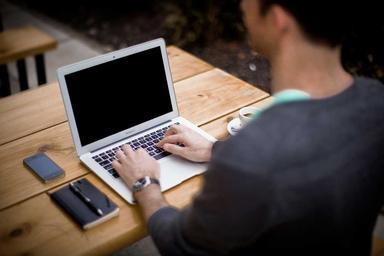

----------------------------------------------------------------------------------------------------
Distance: 0.0850217342376709
Image ID: 0
Author: Alejandro Escamilla
Filename: picsum_0_384x256.jpg


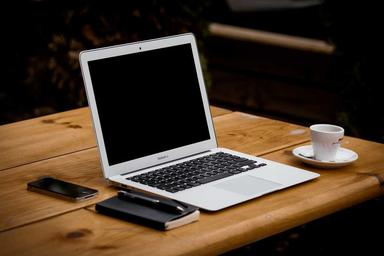

----------------------------------------------------------------------------------------------------
Distance: 0.08665072917938232
Image ID: 3
Author: Alejandro Escamilla
Filename: picsum_3_384x256.jpg


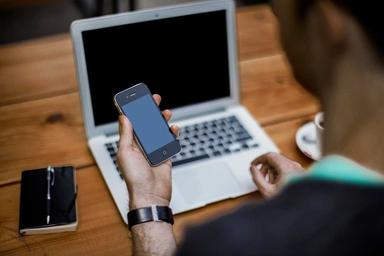

----------------------------------------------------------------------------------------------------
Distance: 0.09246885776519775
Image ID: 6
Author: Alejandro Escamilla
Filename: picsum_6_384x256.jpg


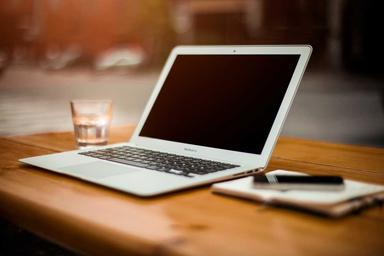

----------------------------------------------------------------------------------------------------


In [26]:
search_images_by_image(
    downloaded_images[5]["local_path"],
    limit=5,
)

In [27]:
def explain_image_search_results(
    query: str,
    *,
    limit: int = 5,
) -> None:
    query_embedding = embed_text_query_with_gemini(query)

    response = image_collection.generate.near_vector(
        near_vector=query_embedding,
        target_vector="image_vector",
        grouped_task=(
            "Act as an image search analyst. "
            "Use only the retrieved image metadata. "
            "Explain why these images may match the user's visual search query. "
            "Be honest that the available metadata is limited and that the ranking mainly comes from visual embeddings."
        ),
        limit=limit,
        return_properties=[
            "image_id",
            "author",
            "filename",
            "image_url",
            "description",
        ],
    )

    print("QUERY:", query)
    print("-" * 100)
    print(response.generated)

    print("\nSources:")
    for obj in response.objects:
        print(
            "-",
            obj.properties["filename"],
            "| author:",
            obj.properties["author"],
            "| image_id:",
            obj.properties["image_id"],
        )

In [28]:
explain_image_search_results(
    "a calm nature photo with water or mountains",
    limit=5,
)

QUERY: a calm nature photo with water or mountains
----------------------------------------------------------------------------------------------------
As an image search analyst, I can explain why these images *may* have been retrieved for your visual search query, based solely on the provided metadata.

**Analysis based on Metadata:**

1.  **Limited Content Information:** The most significant observation is the extreme lack of descriptive content in the metadata. Each image's description is simply "Image from Lorem Picsum. Image id: [ID]. Author: [Author]." This means the metadata does not contain any keywords, tags, or textual descriptions of what is actually *depicted* in the images (e.g., "landscape," "person," "cityscape," "abstract").

2.  **Common Authors:** There are two authors represented in the results:
    *   Paul Jarvis (Image IDs: 10, 11)
    *   Alejandro Escamilla (Image IDs: 0, 6, 9)
    While having common authors *could* sometimes indicate a stylistic similarity or

In [29]:
full_embedding = embed_image_with_gemini(
    downloaded_images[0]["local_path"],
    output_dimensionality=3072,
)

print("Full embedding length:", len(full_embedding))
print("First 10 values:", full_embedding[:10])

Full embedding length: 3072
First 10 values: [-0.009280411, -0.037433434, 0.0074462416, 0.00055708387, -0.003639262, 0.0024211097, -0.0059426143, 0.010829819, -0.009687043, -0.014822364]


In [30]:
client.close()

print("Client closed.")

Client closed.
